# 1D block encoding

Structured block encodings for the 1D negative Laplacian / Poisson operator, following
Sunderhauf et al. (Quantum 8, 1226, 2024) and Pechan et al. (2025) relabeling.

**Sections**
1. Homogeneous periodic Laplacian (Linear Combination of Unitaries (LCU))
2. Modular adders vs dense shifts
3. Dirichlet BC and out-of-bounds oracle $O_{\mathrm{rg}}$
4. Two-material heterogeneous Poisson + QLS paper ($d_{\mathrm{ind}}||d_{\mathrm{val}}$) and $O_{\mathrm{data}}$
5. Clinic-inspired 1D elastic stiffness proxy ($E=\lambda+2\mu$)

In [ ]:
import importlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(os.getcwd()))
import _block_encoding_1d as be1d
import _block_encoding_common as be_common

importlib.reload(be1d)
importlib.reload(be_common)

from _block_encoding_1d import (
    build_laplacian_block_encoding_circuit,
    build_org_dirichlet_circuit,
    clinic_elastic_stiffness_1d,
    compare_shift_implementations,
    laplacian_1d_dirichlet,
    laplacian_1d_periodic,
    pechan_relabel_1d,
    permeability_field_1d_two_material,
    permutation_unitary,
    poisson_matrix_1d,
    summarize_labeling_1d,
    verify_block_encoding,
    gate_budget_1d,
    data_loading_subcircuit
)

## 1. Homogeneous periodic Laplacian

### Finite-difference stencil

Grid points $j \in \{0,\ldots,N-1\}$ with spacing $h=1$ and **periodic** boundary conditions (indices taken mod $N$):
$$
(-\Delta u)_j = 2u_j - u_{j-1} - u_{j+1}.
$$

### Cyclic shift unitaries

Encode the grid index in $n=\log_2 N$ qubits. The cyclic shift unitaries act on computational basis states $|j\rangle$ as
$$
S_+\,|j\rangle = |(j+1)\bmod N\rangle, \qquad
S_-\,|j\rangle = |(j-1)\bmod N\rangle = |(j+N-1)\bmod N\rangle.
$$
In matrix form on the active subspace, $(S_+)_{k,j}=\delta_{k,(j+1)\bmod N}$ and $(S_-)_{k,j}=\delta_{k,(j-1)\bmod N}$. Both are unitary and $S_- = S_+^\dagger$.

When $N=2^n$, $S_+$ can be implemented as a **modular binary increment** on $n$ qubits (Sunderhauf Sec. 3.2, circulant remark); $S_- = S_+^\dagger$ is the decrement.

### Operator as a sum of shifts

The negative Laplacian is a **linear combination of unitaries** (no ancilla yet):
$$
L = 2I - S_- - S_+.
$$

### Linear Combination of Unitaries (LCU) block encoding

Write $L$ as an LCU with coefficients $c_k$ and unitaries $U_k$:
$$
L = \sum_{k=0}^{2} c_k\, U_k, \qquad
\mathbf{c} = (2,\,-1,\,-1), \quad \mathbf{U} = (I,\, S_-,\, S_+).
$$
Define the **one-norm scale**
$$
\beta = \sum_{k}|c_k| = 4.
$$

### Why $\beta = \sum_k |c_k|$ (1-norm, not spectral norm)

PREPARE must output a **valid quantum state**: $\sum_k |a_k|^2 = 1$. We want term $k$ to carry weight $|c_k|$, so set $|a_k|^2 = |c_k|/\beta$, i.e. $a_k = \sqrt{|c_k|/\beta}$. Summing gives $\sum_k |c_k|/\beta = 1$, hence $\beta = \sum_k |c_k|$. Negative $c_k$ cannot enter amplitudes (they must be $\geq 0$); their sign goes into SELECT as $-S_\pm$.

After $U_L = \text{PREPARE}^\dagger\,\text{SELECT}\,\text{PREPARE}$, the block on the index register is $L/\beta$.

**PREPARE** loads ancilla amplitudes $a_k = \sqrt{|c_k|/\beta}$:
$$
\text{PREPARE}\,|0\rangle = \sqrt{\tfrac12}\,|0\rangle + \sqrt{\tfrac14}\,|1\rangle + \sqrt{\tfrac14}\,|2\rangle.
$$
**SELECT** applies term $k$ controlled on $|k\rangle$, with the sign of $c_k$ absorbed into the unitary ($-S_\pm$ for $k=1,2$):
$$
\text{SELECT} = |0\rangle\langle 0|\otimes I \;+\; |1\rangle\langle 1|\otimes(-S_-) \;+\; |2\rangle\langle 2|\otimes(-S_+).
$$
The block-encoding circuit is
$$
U_L = \text{PREPARE}^\dagger\;\text{SELECT}\;\text{PREPARE}.
$$
Starting from ancilla $|0\rangle$, the top-left block on the index register satisfies
$$
(\langle 0|\otimes I)\, U_L\, (|0\rangle\otimes I) = \frac{L}{\beta}.
$$

Sunderhauf Sec. 3.2 encodes the same Toeplitz/circulant matrix via $(d,m)$ oracles; Sec. 3.5 eq. (75) gives the stencil. We use the equivalent PREPARE--SELECT LCU.

In [2]:
N = 8
n_qubits = int(np.log2(N))

S_plus = permutation_unitary(n_qubits, N, +1)[:N, :N]
S_minus = permutation_unitary(n_qubits, N, -1)[:N, :N]
I = np.eye(N)

L_from_shifts = 2 * I - S_minus - S_plus
L = laplacian_1d_periodic(N)

coefficients = np.array([2.0, -1.0, -1.0])
alpha_lcu = np.sum(np.abs(coefficients))
prepare_amps = np.sqrt(np.abs(coefficients) / alpha_lcu)

print("L = 2I - S_- - S_+  (max entry error):", np.max(np.abs(L_from_shifts - L)))
print("LCU scale alpha = sum|c_k| =", alpha_lcu)
print("PREPARE amplitudes a_k = sqrt(|c_k|/alpha):", prepare_amps)
print("\nS_+ (cyclic right shift):")
print(S_plus.astype(int))

L = 2I - S_- - S_+  (max entry error): 0.0
LCU scale alpha = sum|c_k| = 4.0
PREPARE amplitudes a_k = sqrt(|c_k|/alpha): [0.70710678 0.5        0.5       ]

S_+ (cyclic right shift):
[[0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]]


/var/folders/rz/cl2sc98s2wd19xqm4w018p400000gq/T/ipykernel_48692/3411024376.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  print(S_plus.astype(int))


In [3]:
circuit, _, alpha = build_laplacian_block_encoding_circuit(N, use_adders=True)
err = verify_block_encoding(circuit, L, alpha)
print(f"alpha = {alpha:.4f}, max error = {err:.2e}")
assert err < 1e-10

alpha = 4.0000, max error = 7.07e-14


## 2. Modular adders ($O(\log N)$) vs dense `UnitaryGate` shifts

Section 1 builds SELECT from shifts $S_\pm$. Two implementations of the **same** unitary:

| Approach | Implementation | Scaling |
|----------|----------------|--------|
| **Dense** (`use_adders=False`) | Full $2^n \times 2^n$ permutation matrix as `UnitaryGate` | Synthesis cost grows rapidly with $n$ |
| **Modular adders** (`use_adders=True`) | `increment_gate` / `decrement_gate` ($\pm 1$) | $O(n)$ structured gates (Sunderhauf Sec. 3.2) |

Sunderhauf Sec. 3.2: circulant index updates are modular additions (eq. (51) mod $N$), not black-box $N$-point permutations.
 
*Note: theoretically adders have less number of CNOTs, but here we see the opposite -- the number is almost the same (with some noise). Therefore, this method needs additional verification and comparison with T-gate count.*

In [4]:
# Gate counts at several grid sizes.
for n_grid in (4, 8, 16, 32, 64, 128, 256):
    counts = compare_shift_implementations(n_grid)
    print(f"N={n_grid:2d}  dense CNOTs={counts['dense_two_qubit_gates']:5d}  "
          f"adder CNOTs={counts['adder_two_qubit_gates']:5d}")

N= 4  dense CNOTs=  168  adder CNOTs=  168
N= 8  dense CNOTs=  803  adder CNOTs=  803
N=16  dense CNOTs= 3543  adder CNOTs= 3543
N=32  dense CNOTs=15028  adder CNOTs=15038
N=64  dense CNOTs=61164  adder CNOTs=61253
N=128  dense CNOTs=245181  adder CNOTs=245638
N=256  dense CNOTs=979162  adder CNOTs=981482


## 3. Dirichlet BC and $O_{\mathrm{rg}}$ (QLS paper Appendix E)

Homogeneous Dirichlet Laplacian. Invalid boundary shifts are marked by $O_{\mathrm{rg}}$ on a delete qubit.

          
q_0: ──■──
       │  
q_1: ──■──
       │  
q_2: ──■──
     ┌─┴─┐
q_3: ┤ X ├
     └───┘
          
q_0: ──o──
       │  
q_1: ──o──
       │  
q_2: ──o──
     ┌─┴─┐
q_3: ┤ X ├
     └───┘


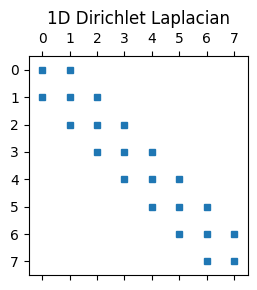

In [5]:
L_d = laplacian_1d_dirichlet(N)
n_qubits = int(np.log2(N))

org_plus = build_org_dirichlet_circuit(n_qubits, N, delta=1)
org_minus = build_org_dirichlet_circuit(n_qubits, N, delta=-1)
print(org_plus.draw(output="text"))
print(org_minus.draw(output="text"))

fig, ax = plt.subplots(figsize=(4, 3))
ax.spy(L_d, markersize=4)
ax.set_title("1D Dirichlet Laplacian")
plt.tight_layout()
plt.show()

## 4. Two-material 1D Poisson + QLS paper relabeling

Piecewise constant $k(x)$. Relabel $d = d_{\mathrm{ind}}\|d_{\mathrm{val}}$ (sections: diag / right / left).

In [6]:
k = permeability_field_1d_two_material(N, k_rock=1.0, k_fracture=5.0)
G = poisson_matrix_1d(k, periodic=False)
labeling = pechan_relabel_1d(G)
summary = summarize_labeling_1d(labeling)
print(summary)

rows = []
for d_label, value in labeling.d_to_value.items():
    section, d_val = labeling.d_ind_map[d_label]
    rows.append({"d": d_label, "section": section, "d_val": d_val, "A_d": value})
pd.DataFrame(rows).sort_values("d")

{'N': 8, 'D_prime': 12, 'D_padded': 32, 'D_init_sections': {'diagonal': 6, 'right': 3, 'left': 3}, 'spectral_norm': 17.446590770551868, 'value_table': array([ 1.,  2.,  4.,  5.,  8., 10.,  0.,  0., -5., -3., -1.,  0.,  0.,
        0.,  0.,  0., -5., -3., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.])}


,d,section,d_val,A_d
0,0,0,0,1.0
3,1,0,1,2.0
4,2,0,2,4.0
11,3,0,3,5.0
7,4,0,4,8.0
10,5,0,5,10.0
8,8,1,0,-5.0
5,9,1,1,-3.0
1,10,1,2,-1.0
9,16,2,0,-5.0


In [7]:
alpha = summary["spectral_norm"]
odata = data_loading_subcircuit(labeling.value_table, alpha)
budget = gate_budget_1d(labeling)
print(odata.draw(output="text", fold=100))
print("O_data CNOTs:", budget["O_data"]["two_qubit_gates"])

     ┌────────────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐»
q_0: ┤ Ry(3.0269) ├┤ RY(1) ├┤ RY(2) ├┤ RY(3) ├┤ RY(4) ├┤ RY(5) ├┤ RY(6) ├┤ RY(7) ├┤ RY(8) ├»
     └────────────┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘»
q_1: ──────────────────■────────o────────■────────o────────■────────o────────■────────o────»
                       │        │        │        │        │        │        │        │    »
q_2: ──────────────────o────────■────────■────────o────────o────────■────────■────────o────»
                       │        │        │        │        │        │        │        │    »
q_3: ──────────────────o────────o────────o────────■────────■────────■────────■────────o────»
                       │        │        │        │        │        │        │        │    »
q_4: ──────────────────o────────o────────o────────o────────o────────o────────o────────■────»
                       │        │        │        │        │        │ 

## 5. Clinic elastic stiffness proxy (1D)

Use clinic material parameters with $E=\lambda+2\mu$ on a 1D rock/fracture chain.
Full 3D $\mathbf{H}=i\mathbf{B}^{-1/2}\mathbf{A}\mathbf{B}^{-1/2}$ is future work.

In [8]:
G_clinic, stiffness = clinic_elastic_stiffness_1d(N)
label_clinic = pechan_relabel_1d(G_clinic)
print(summarize_labeling_1d(label_clinic))
print("E_rock =", stiffness[0], "E_fracture =", stiffness[-1])
print("O_data CNOTs:", gate_budget_1d(label_clinic)["O_data"]["two_qubit_gates"])

{'N': 8, 'D_prime': 12, 'D_padded': 32, 'D_init_sections': {'diagonal': 6, 'right': 3, 'left': 3}, 'spectral_norm': 131348442691.31746, 'value_table': array([ 2.20e+09,  4.40e+09,  2.22e+10,  3.78e+10,  5.78e+10,  7.56e+10,
        0.00e+00,  0.00e+00, -3.78e+10, -2.00e+10, -2.20e+09,  0.00e+00,
        0.00e+00,  0.00e+00,  0.00e+00,  0.00e+00, -3.78e+10, -2.00e+10,
       -2.20e+09,  0.00e+00,  0.00e+00,  0.00e+00,  0.00e+00,  0.00e+00,
        0.00e+00,  0.00e+00,  0.00e+00,  0.00e+00,  0.00e+00,  0.00e+00,
        0.00e+00,  0.00e+00])}
E_rock = 37800000000.0 E_fracture = 2200000000.000002
O_data CNOTs: 1240


## Summary

| Step | Covered here |
|------|----------------|
| Modular adders | `increment_gate` / `decrement_gate` |
| Dirichlet + $O_{\mathrm{rg}}$ | matrix + oracle circuits |
| Two-material QLS + $O_{\mathrm{data}}$ | Sec. 4 |
| Clinic elastic proxy | Sec. 5 (1D $E=\lambda+2\mu$) |